<a href="https://colab.research.google.com/github/Bishesh-P/Graduate-Admission-Prediction-Using-ANN/blob/main/Graduate_Admission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('admission_data.csv')

In [3]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.shape

(500, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


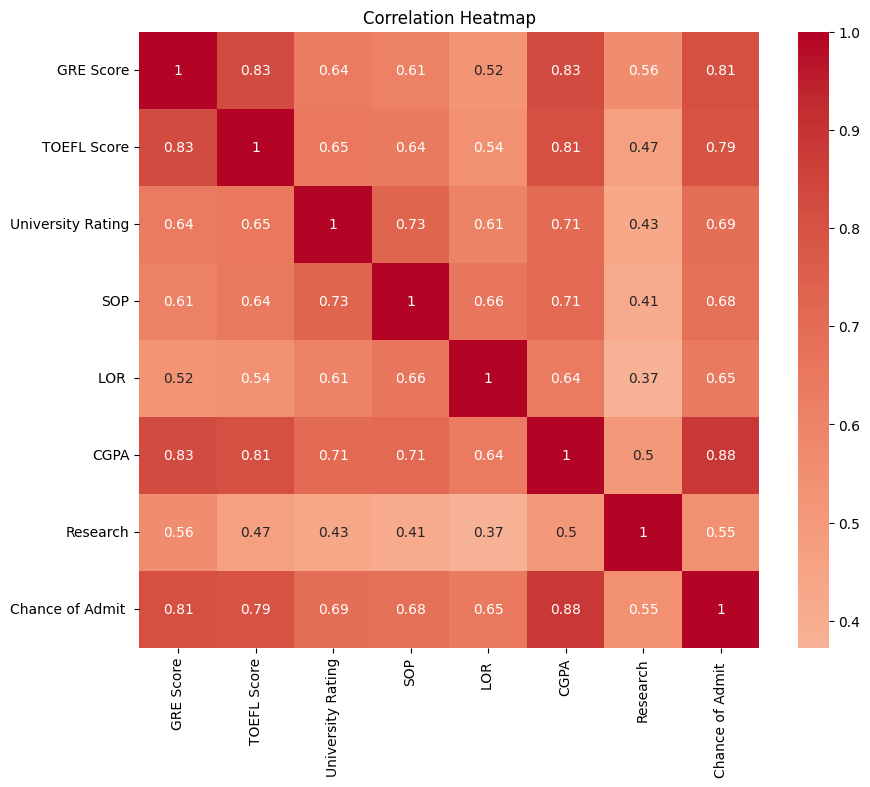

In [8]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

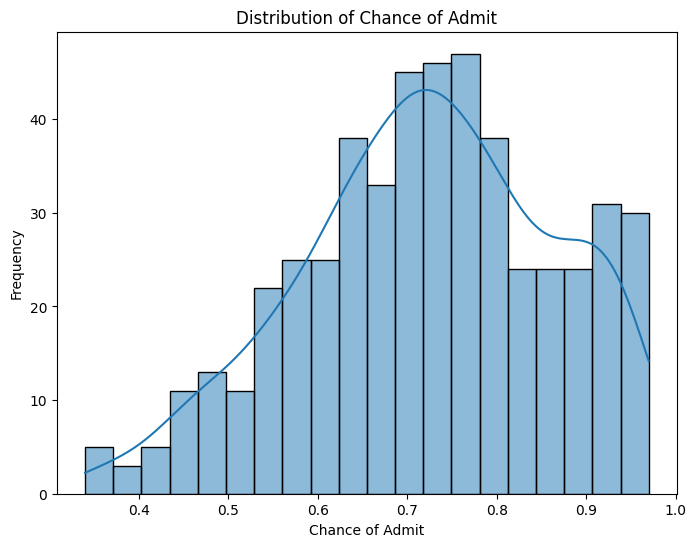

In [9]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Chance of Admit '], bins=20, kde=True)
plt.title('Distribution of Chance of Admit')
plt.xlabel('Chance of Admit')
plt.ylabel('Frequency')
plt.show()

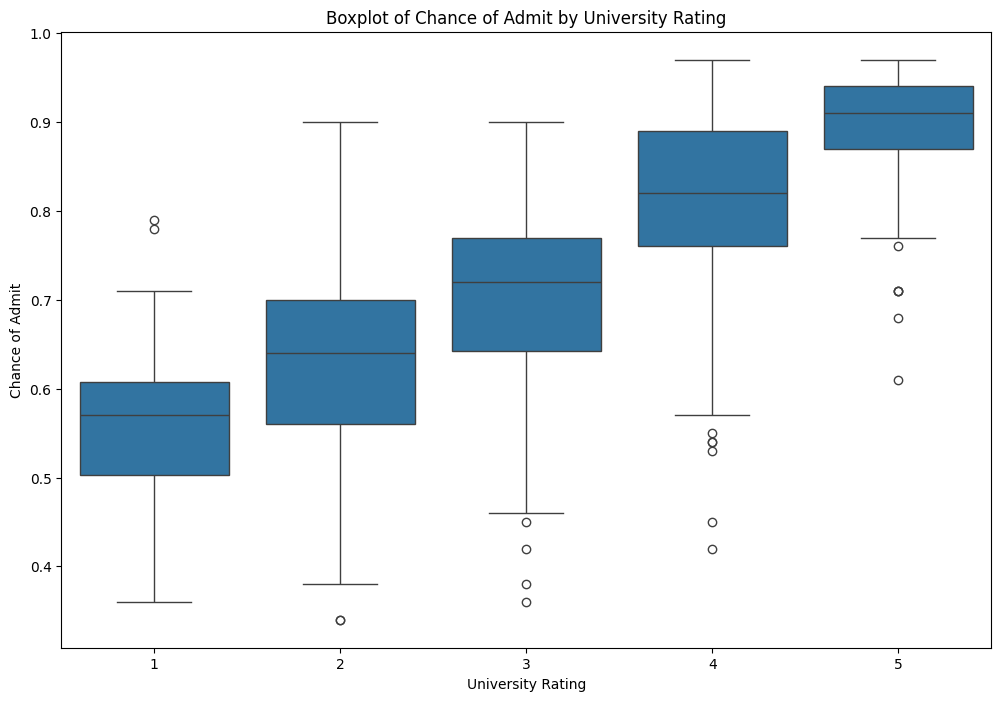

In [10]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='University Rating', y='Chance of Admit ')
plt.title('Boxplot of Chance of Admit by University Rating')
plt.xlabel('University Rating')
plt.ylabel('Chance of Admit')
plt.show()

In [11]:
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [14]:
# here we use min max scaler because , we have lower and upperbound values for the column.
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_trained_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model=Sequential()
#hidden layer with 7 units and relu activation function, expecting input of dimension 7
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu',))
model.add(Dense(7,activation='relu',))
#output layer with 1 units
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176 (704.00 B)

 Trainable params: 176 (704.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [19]:
history=model.fit(X_trained_scaled,y_train,epochs=150,validation_split=0.2)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.5110 - val_loss: 0.4874
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4452 - val_loss: 0.4121
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3746 - val_loss: 0.3349
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2997 - val_loss: 0.2541
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2236 - val_loss: 0.1759
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1512 - val_loss: 0.1075
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0898 - val_loss: 0.0558
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0462 - val_loss: 0.0251
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0227 - val_loss: 0.0147
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0150 - val_loss: 0.0150
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0141 - val_loss: 0.0147
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

In [20]:
y_pred=model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [21]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7448966621238768

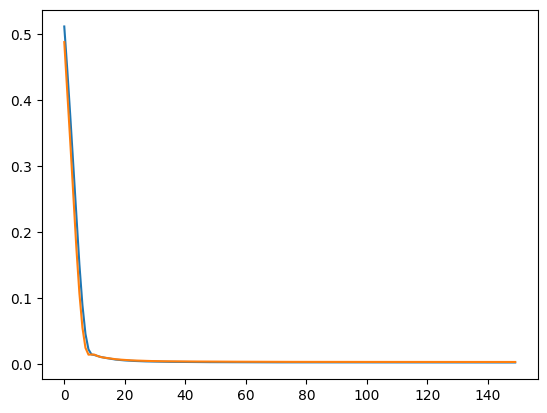

In [22]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])